Rows after cleaning: 4022
Features used: ['ma_gap_20', 'vol_10', 'vol_20', 'lower_wick', 'upper_wick', 'ret_1', 'range_pct', 'co_ret', 'ret_5']
=== Accuracy ===
Scratch: 0.3803
Library: 0.3853

=== Confusion Matrix ===
Scratch:
 [[ 13  79  67]
 [ 38 207 150]
 [ 32 131  85]]
Library:
 [[ 13  79  67]
 [ 38 207 150]
 [ 31 128  89]]

=== Precision / Recall / F1 (Macro) ===
Scratch - P:0.3115 R:0.3162 F1:0.3088
Library - P:0.3165 R:0.3216 F1:0.3136

=== Log Loss ===
Scratch: 22.3363
Library: 1.4425

=== ROC AUC ===
Scratch AUC: 0.4887
Library AUC: 0.4984


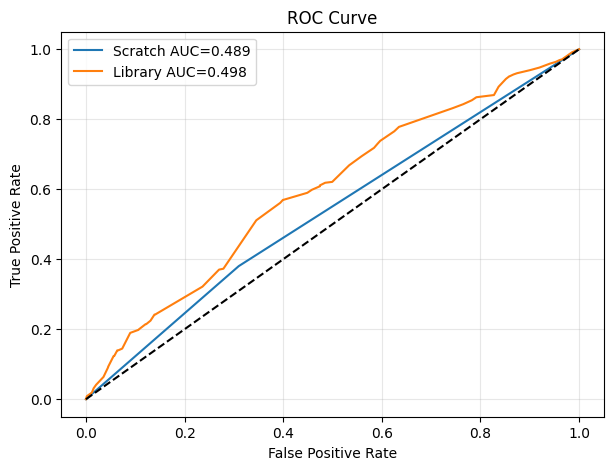

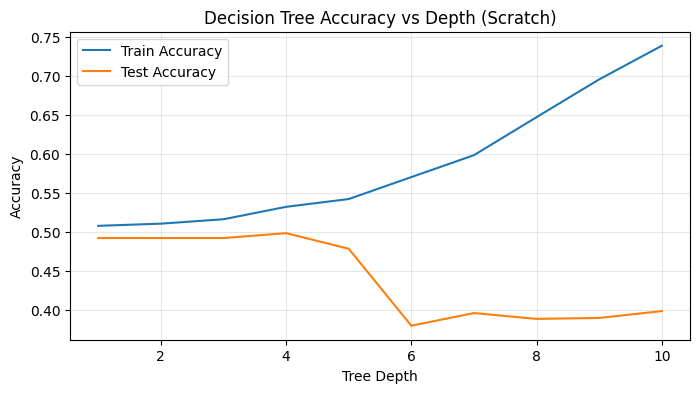

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    mean_squared_error,
    r2_score,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

WINDOW_SIZE = 14
DATA_PATH = '../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv'
FEATURE_PATH = '../CLASSIFY-AMZN_methods_all_in_one.csv'
TARGET_COL = 'Target_Return_7d'

UP_THRESHOLD = 0.03
DOWN_THRESHOLD = -0.03

# --------------------------
# 1) Load data
# --------------------------
df = pd.read_csv(DATA_PATH)
feature_df = pd.read_csv(FEATURE_PATH)

requested_features = [
    'ma_gap_20', 'vol_10', 'vol_20',
    'lower_wick', 'upper_wick',
    'ret_1', 'range_pct',
    'co_ret', 'ret_5'
]

allowed_features = feature_df['feature'].tolist() if 'feature' in feature_df.columns else []
feature_cols = [c for c in requested_features if c in allowed_features and c in df.columns]

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

model_df = df[feature_cols + [TARGET_COL]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f'Rows after cleaning: {len(model_df)}')
print('Features used:', feature_cols)

# --------------------------
# 2) Sliding Window
# --------------------------
def make_windows(x_values, y_values, window_size=14):
    Xw, yw = [], []
    for i in range(window_size, len(x_values)):
        Xw.append(x_values[i-window_size:i].reshape(-1))
        yw.append(y_values[i])
    return np.array(Xw), np.array(yw)

def map_target_3class(y_values, up_thr=0.03, down_thr=-0.03):
    y_cls = np.full_like(y_values, 1, dtype=np.int64)
    y_cls[y_values > up_thr] = 2
    y_cls[y_values < down_thr] = 0
    return y_cls

CLASS_LABELS = {0: 'Downtrend', 1: 'Sideway', 2: 'Uptrend'}

X_raw = model_df[feature_cols].values
y_raw_cont = model_df[TARGET_COL].values
y_raw = map_target_3class(y_raw_cont)

X_win, y_win = make_windows(X_raw, y_raw, WINDOW_SIZE)

split_idx = int(len(X_win) * 0.8)
X_train_raw, X_test_raw = X_win[:split_idx], X_win[split_idx:]
y_train, y_test = y_win[:split_idx], y_win[split_idx:]

# Standardize
x_mean = X_train_raw.mean(axis=0)
x_std = X_train_raw.std(axis=0)
x_std = np.where(x_std == 0, 1, x_std)

X_train = (X_train_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

# ------------------------------------------
# 3) Decision Tree from scratch
# ------------------------------------------
class DecisionTreeScratch:
    def __init__(self, max_depth=6, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / counts.sum()
        return 1 - np.sum(probs**2)

    def _best_split(self, X, y):
        best_gini = 1e9
        best_feature, best_threshold = None, None

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for t in thresholds:
                left = y[X[:, feature] <= t]
                right = y[X[:, feature] > t]
                if len(left) == 0 or len(right) == 0:
                    continue
                gini = (len(left)/len(y))*self._gini(left) + \
                       (len(right)/len(y))*self._gini(right)
                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = t
        return best_feature, best_threshold

    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples_split:
            return np.bincount(y).argmax()

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.bincount(y).argmax()

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        return {
            'feature': feature,
            'threshold': threshold,
            'left': self._build(X[left_mask], y[left_mask], depth+1),
            'right': self._build(X[right_mask], y[right_mask], depth+1)
        }

    def fit(self, X, y):
        self.tree = self._build(X, y, 0)

    def _predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

# Train scratch
scratch_model = DecisionTreeScratch(max_depth=6, min_samples_split=10)
scratch_model.fit(X_train, y_train)
y_pred_scratch = scratch_model.predict(X_test)
y_prob_scratch = np.eye(3)[y_pred_scratch]

# ------------------------------------------
# 4) Library Decision Tree
# ------------------------------------------
lib_model = DecisionTreeClassifier(max_depth=6, min_samples_split=10)
lib_model.fit(X_train, y_train)
y_pred_lib = lib_model.predict(X_test)
y_prob_lib = lib_model.predict_proba(X_test)

# ------------------------
# 5) Metrics
# ------------------------
classes = np.array([0,1,2])

loss_scratch = log_loss(y_test, y_prob_scratch, labels=classes)
loss_lib = log_loss(y_test, y_prob_lib, labels=classes)

cm_scratch = confusion_matrix(y_test, y_pred_scratch, labels=classes)
cm_lib = confusion_matrix(y_test, y_pred_lib, labels=classes)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
acc_lib = accuracy_score(y_test, y_pred_lib)

precision_scratch = precision_score(y_test, y_pred_scratch, average='macro', zero_division=0)
precision_lib = precision_score(y_test, y_pred_lib, average='macro', zero_division=0)

recall_scratch = recall_score(y_test, y_pred_scratch, average='macro', zero_division=0)
recall_lib = recall_score(y_test, y_pred_lib, average='macro', zero_division=0)

f1_scratch = f1_score(y_test, y_pred_scratch, average='macro', zero_division=0)
f1_lib = f1_score(y_test, y_pred_lib, average='macro', zero_division=0)

print("=== Accuracy ===")
print(f"Scratch: {acc_scratch:.4f}")
print(f"Library: {acc_lib:.4f}")

print("\n=== Confusion Matrix ===")
print("Scratch:\n", cm_scratch)
print("Library:\n", cm_lib)

print("\n=== Precision / Recall / F1 (Macro) ===")
print(f"Scratch - P:{precision_scratch:.4f} R:{recall_scratch:.4f} F1:{f1_scratch:.4f}")
print(f"Library - P:{precision_lib:.4f} R:{recall_lib:.4f} F1:{f1_lib:.4f}")

print("\n=== Log Loss ===")
print(f"Scratch: {loss_scratch:.4f}")
print(f"Library: {loss_lib:.4f}")

# ------------------------
# 6) ROC Curve
# ------------------------
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_s = roc_auc_score(y_test_bin, y_prob_scratch, average='macro', multi_class='ovr')
roc_auc_l = roc_auc_score(y_test_bin, y_prob_lib, average='macro', multi_class='ovr')

fpr_s, tpr_s, _ = roc_curve(y_test_bin.ravel(), y_prob_scratch.ravel())
fpr_l, tpr_l, _ = roc_curve(y_test_bin.ravel(), y_prob_lib.ravel())

print("\n=== ROC AUC ===")
print(f"Scratch AUC: {roc_auc_s:.4f}")
print(f"Library AUC: {roc_auc_l:.4f}")

plt.figure(figsize=(7,5))
plt.plot(fpr_s, tpr_s, label=f"Scratch AUC={roc_auc_s:.3f}")
plt.plot(fpr_l, tpr_l, label=f"Library AUC={roc_auc_l:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------
# 7) Accuracy vs Depth
# ------------------------
depth_range = range(1,11)
train_acc = []
test_acc = []

for d in depth_range:
    model = DecisionTreeScratch(max_depth=d)
    model.fit(X_train, y_train)
    train_acc.append(np.mean(model.predict(X_train)==y_train))
    test_acc.append(np.mean(model.predict(X_test)==y_test))

plt.figure(figsize=(8,4))
plt.plot(depth_range, train_acc, label="Train Accuracy")
plt.plot(depth_range, test_acc, label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Depth (Scratch)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()